In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("web_traffic_sample.csv")

df.head()

,SessionID,Date,PagePath,Source,DeviceCategory,SessionDurationSec,PageViews,Converted,BounceRate
0,SESS-5001,10-06-2026,/landing,Google Search,Mobile,145,3,Yes,0
1,SESS-5002,10-06-2026,/courses,Direct,Desktop,420,8,Yes,0
2,SESS-5003,10-06-2026,/blog/python,LinkedIn,Mobile,45,1,No,1
3,SESS-5004,11-06-2026,/register,Google Ads,Desktop,210,4,Yes,0
4,SESS-5005,11-06-2026,/pricing,Direct,Desktop,60,2,No,0


In [4]:
df.shape

(10, 9)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   SessionID           10 non-null     object
 1   Date                10 non-null     object
 2   PagePath            10 non-null     object
 3   Source              10 non-null     object
 4   DeviceCategory      10 non-null     object
 5   SessionDurationSec  10 non-null     int64 
 6   PageViews           10 non-null     int64 
 7   Converted           10 non-null     object
 8   BounceRate          10 non-null     int64 
dtypes: int64(3), object(6)
memory usage: 848.0+ bytes


In [6]:
df.columns

Index(['SessionID', 'Date', 'PagePath', 'Source', 'DeviceCategory',
       'SessionDurationSec', 'PageViews', 'Converted', 'BounceRate'],
      dtype='object')

In [7]:
df.isnull().sum()

SessionID             0
Date                  0
PagePath              0
Source                0
DeviceCategory        0
SessionDurationSec    0
PageViews             0
Converted             0
BounceRate            0
dtype: int64

In [10]:
df["BounceRate"].value_counts()

BounceRate
0    7
1    3
Name: count, dtype: int64

In [11]:
bounce_rate = df["BounceRate"].mean() * 100

print("Bounce Rate:", bounce_rate, "%")

Bounce Rate: 30.0 %


In [12]:
avg_duration = df["SessionDurationSec"].mean()

print("Average Session Duration:", avg_duration, "seconds")

Average Session Duration: 170.5 seconds


In [13]:
avg_duration_min = df["SessionDurationSec"].mean() / 60

print("Average Session Duration:", avg_duration_min, "minutes")

Average Session Duration: 2.841666666666667 minutes


In [14]:
avg_pageviews = df["PageViews"].mean()

print("Average Pageviews per Session:", avg_pageviews)

Average Pageviews per Session: 3.4


In [15]:
df["Source"].value_counts()

Source
Direct           3
Google Search    2
Google Ads       2
LinkedIn         1
Facebook         1
Twitter          1
Name: count, dtype: int64

In [16]:
conversion_by_source = df.groupby("Source")["Converted"].apply(
    lambda x: (x == "Yes").mean() * 100
)

print(conversion_by_source)

Source
Direct            33.333333
Facebook           0.000000
Google Ads       100.000000
Google Search    100.000000
LinkedIn           0.000000
Twitter            0.000000
Name: Converted, dtype: float64


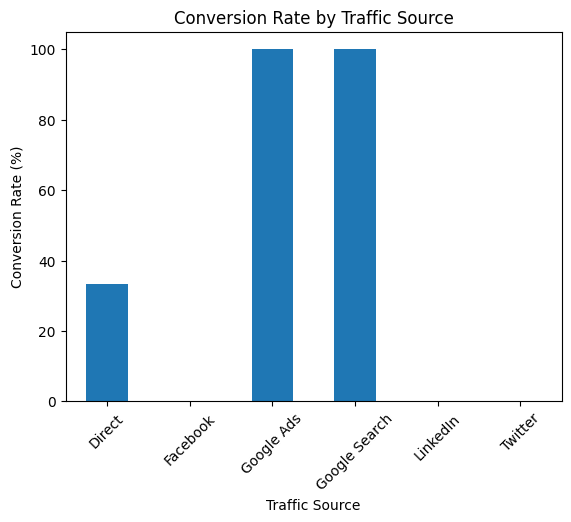

In [17]:
conversion_by_source.plot(kind="bar")

plt.title("Conversion Rate by Traffic Source")
plt.xlabel("Traffic Source")
plt.ylabel("Conversion Rate (%)")
plt.xticks(rotation=45)

plt.show()

In [18]:
traffic_source = df["Source"].value_counts()

print(traffic_source)

Source
Direct           3
Google Search    2
Google Ads       2
LinkedIn         1
Facebook         1
Twitter          1
Name: count, dtype: int64


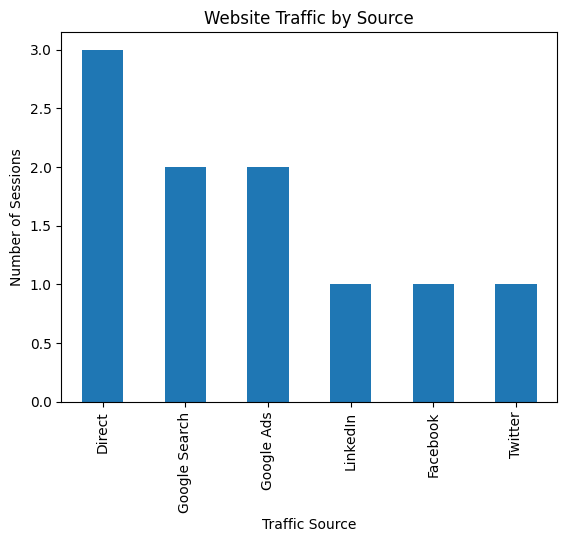

In [19]:
traffic_source.plot(kind="bar")

plt.title("Website Traffic by Source")
plt.xlabel("Traffic Source")
plt.ylabel("Number of Sessions")

plt.show()

In [20]:
duration_by_source = df.groupby("Source")["SessionDurationSec"].mean()

print(duration_by_source)

Source
Direct           220.0
Facebook          15.0
Google Ads       250.0
Google Search    227.5
LinkedIn          45.0
Twitter           30.0
Name: SessionDurationSec, dtype: float64


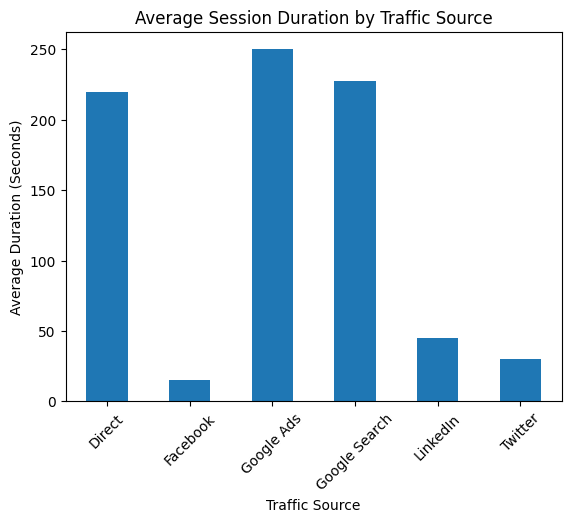

In [21]:
duration_by_source.plot(kind="bar")

plt.title("Average Session Duration by Traffic Source")
plt.xlabel("Traffic Source")
plt.ylabel("Average Duration (Seconds)")

plt.xticks(rotation=45)
plt.show()

In [22]:
pageviews_by_source = df.groupby("Source")["PageViews"].mean()

print(pageviews_by_source)

Source
Direct           4.333333
Facebook         1.000000
Google Ads       4.500000
Google Search    4.500000
LinkedIn         1.000000
Twitter          1.000000
Name: PageViews, dtype: float64


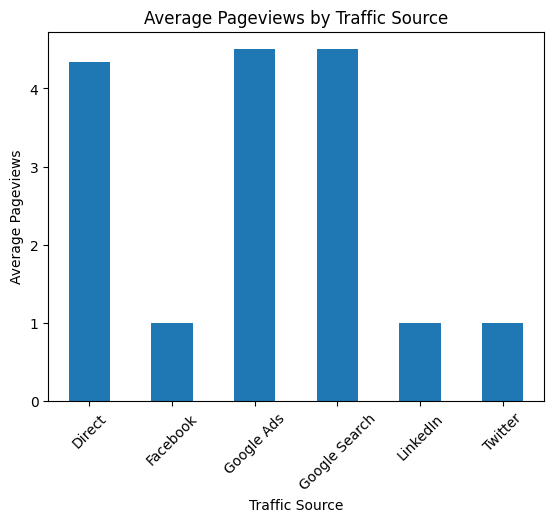

In [23]:
pageviews_by_source.plot(kind="bar")

plt.title("Average Pageviews by Traffic Source")
plt.xlabel("Traffic Source")
plt.ylabel("Average Pageviews")

plt.xticks(rotation=45)
plt.show()

In [24]:
df["PagePath"].value_counts()

PagePath
/landing                 3
/courses                 1
/blog/python             1
/register                1
/pricing                 1
/courses/data-science    1
/blog/ai-trends          1
/contact                 1
Name: count, dtype: int64

In [25]:
page_conversion = df.groupby("PagePath")["Converted"].apply(
    lambda x: (x == "Yes").mean() * 100
)

print(page_conversion)

PagePath
/blog/ai-trends            0.000000
/blog/python               0.000000
/contact                   0.000000
/courses                 100.000000
/courses/data-science    100.000000
/landing                  66.666667
/pricing                   0.000000
/register                100.000000
Name: Converted, dtype: float64


In [26]:
page_bounce = df.groupby("PagePath")["BounceRate"].mean() * 100

print(page_bounce)

PagePath
/blog/ai-trends          100.000000
/blog/python             100.000000
/contact                   0.000000
/courses                   0.000000
/courses/data-science      0.000000
/landing                  33.333333
/pricing                   0.000000
/register                  0.000000
Name: BounceRate, dtype: float64


In [27]:
page_conversion.sort_values()

PagePath
/blog/ai-trends            0.000000
/blog/python               0.000000
/contact                   0.000000
/pricing                   0.000000
/landing                  66.666667
/courses                 100.000000
/courses/data-science    100.000000
/register                100.000000
Name: Converted, dtype: float64

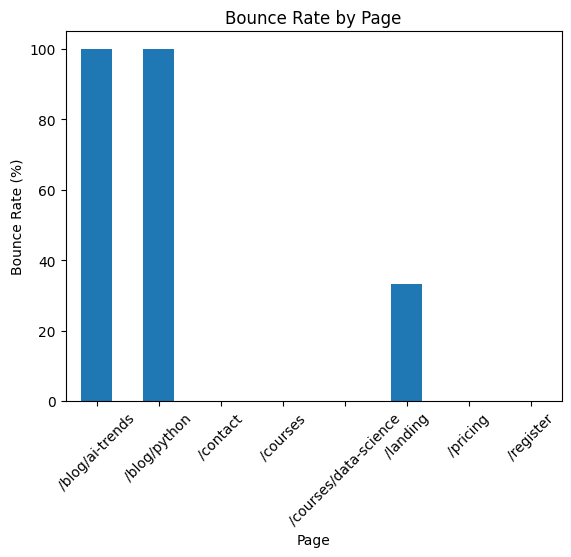

In [28]:
page_bounce.plot(kind="bar")

plt.title("Bounce Rate by Page")
plt.xlabel("Page")
plt.ylabel("Bounce Rate (%)")

plt.xticks(rotation=45)
plt.show()

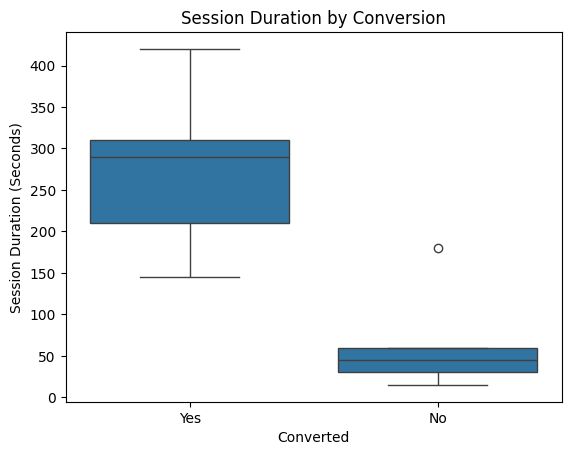

In [29]:
sns.boxplot(
    x="Converted",
    y="SessionDurationSec",
    data=df
)

plt.title("Session Duration by Conversion")
plt.xlabel("Converted")
plt.ylabel("Session Duration (Seconds)")

plt.show()

In [30]:
numeric_cols = [
    "SessionDurationSec",
    "PageViews",
    "BounceRate"
]

correlation = df[numeric_cols].corr()

print(correlation)

                    SessionDurationSec  PageViews  BounceRate
SessionDurationSec            1.000000   0.989552   -0.705088
PageViews                     0.989552   1.000000   -0.699854
BounceRate                   -0.705088  -0.699854    1.000000


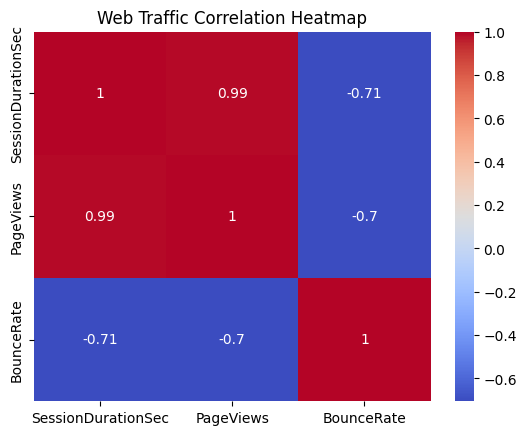

In [31]:
sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm"
)

plt.title("Web Traffic Correlation Heatmap")

plt.show()